In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4


In [4]:
df.columns #displays column names in a dataframe

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [5]:
df.shape #displays rows and columns in a tuple

(4000, 28)

In [6]:
#changing the target column to the last for easy identification
df.columns = [
    'Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct','Profit_INR'
]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_INR
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
df.info() #shows column related info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe() #shows statistics

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_INR
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

Missing values:


Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct             0
Profit_INR                  

Duplicate rows: 0


In [10]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Profit_INR'],
      dtype='object')

In [11]:
#Find Unique Values of All Categorical Columns
df.State.nunique()

8

In [12]:
categorical_columns = ['Farm_ID', 'State', 'District', 'Crop', 'Season']

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

 State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

 District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

 Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

 Season
['Kharif' 'Rabi' 'Zaid']


In [13]:
#Remove Duplicate Rows
df = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [14]:
df_model = df.sample(n=4000, random_state=42).reset_index(drop=True)

print("Rows selected:", len(df_model))
df_model.head()

Rows selected: 4000


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_INR
0,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
1,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
2,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
4,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [15]:
#Separate Input (X) and Target (y)
X = df_model.drop('Profit_INR', axis=1)
y = df_model['Profit_INR']

print("Input features:", X.columns.tolist())
print("Target:", y.name)

Input features: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Target: Profit_INR


In [16]:
#Separate Numerical and Categorical Features
numerical_columns = [
'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

categorical_columns = [
    'Farm_ID', 'State', 'District', 'Crop', 'Season','Irrigation_Method'
]

X_num = X[numerical_columns].copy()
X_cat = X[categorical_columns].copy()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [17]:
#Convert Categorical Columns into Numbers — Label Encoding
# Create one LabelEncoder for each categorical column

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    X_cat[column] = encoder.fit_transform(X_cat[column])

    label_encoders[column] = encoder

X_cat

,Farm_ID,State,District,Crop,Season,Irrigation_Method
0,555,0,6,0,1,1
1,3491,5,9,7,0,0
2,527,4,2,1,0,0
3,3925,3,6,7,1,2
4,2989,1,8,0,1,1
...,...,...,...,...,...,...
3995,1130,4,1,2,1,0
3996,1294,1,3,4,0,1
3997,860,7,7,6,1,2
3998,3507,0,3,7,2,2


In [18]:
#Combine Numerical and Encoded Categorical Data
# Numerical + Label Encoded Categorical columns

X_final = pd.concat(
    [X_num.reset_index(drop=True),
     X_cat.reset_index(drop=True)],
    axis=1
)

print("Final number of features:", X_final.shape[1])
X_final.head()

Final number of features: 27


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Revenue_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Farm_ID,State,District,Crop,Season,Irrigation_Method
0,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,...,1452831,833674,6146,2.545,555,0,6,0,1,1
1,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,...,276048,-404514,5818,2.009,3491,5,9,7,0,0
2,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,...,518822,77009,4491,1.654,527,4,2,1,0,0
3,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,...,293672,-451298,3347,3.293,3925,3,6,7,1,2
4,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,...,1623893,629186,10975,1.363,2989,1,8,0,1,1


In [19]:
#Split into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.25,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3000
Testing rows: 1000


In [20]:
#Scale Numerical Features
scaler = StandardScaler()

# Learn from training data + scale training data
X_train_num = scaler.fit_transform(
    X_train[numerical_columns]
)

# Use the SAME scaler for test data
X_test_num = scaler.transform(
    X_test[numerical_columns]
)

print("Scaled training data:")
print(X_train_num[:5])

Scaled training data:
[[-1.08567139  1.50775117  0.97609648  1.04366922  1.51050415 -0.43741305
  -0.12754325  0.62592851 -0.17133911 -0.92046093 -1.2265847  -0.83632614
   0.8258821   3.50534483  0.99940943 -1.37621197 -1.12790941 -0.11380282
   0.48469419 -0.52157001  5.52453844]
 [-1.10696117  0.6833453   1.70995763  1.11098029  0.33978013  2.03859695
   0.79518195 -0.02569917 -0.31874703  0.72915357  0.50600902 -0.31655966
   1.31740056 -0.35410684 -0.32387555 -0.89121135 -1.00136085 -0.96231499
  -0.57486343 -0.91839897 -0.43227107]
 [-0.80417323  0.04679189 -0.62267245 -0.44558801  0.97016999 -0.99105504
  -1.27716808  0.46863907 -0.82583028 -1.22953903 -0.86880244 -1.06845486
   1.71061534  3.30645097  1.39780481 -1.37112963 -0.88494529  0.20425023
   0.72286639  0.21971084  2.83499217]
 [ 1.68436515 -1.13117789 -0.85855639 -0.33620753  0.42983582 -1.68310753
   0.09935639 -1.14598518  0.22961044 -1.79378626  0.77600212  0.87436161
   1.61231164 -0.33436928 -0.25072226 -0.734120

In [21]:
#Create Final Training and Testing Data
# Numerical columns were scaled.
# Categorical columns were already Label Encoded.

X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_columns,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_columns,
    index=X_test.index
)

# Select the already encoded categorical columns
X_train_cat = X_cat.loc[X_train.index]
X_test_cat = X_cat.loc[X_test.index]

# Combine numerical + categorical features
X_train_final = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)
y_train.shape

Training shape: (3000, 27)
Testing shape: (1000, 27)


(3000,)

In [25]:
print(X_train.isnull().sum())
#linearregression not allowing NaN values...so to get nd understand where those NaN values are, this step is performed

Farm_Area_Hectares                0
Rainfall_mm                      36
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                28
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  25
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct             0
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Irrigation_Method                 0
dtype: int64


In [26]:
#filling NaN values with median for now
X_train['Rainfall_mm'] = X_train['Rainfall_mm'].fillna(
    X_train['Rainfall_mm'].median()
)

X_train['Soil_Moisture_pct'] = X_train['Soil_Moisture_pct'].fillna(
    X_train['Soil_Moisture_pct'].median()
)

X_train['Yield_Tonnes_Ha'] = X_train['Yield_Tonnes_Ha'].fillna(
    X_train['Yield_Tonnes_Ha'].median()
)

In [28]:
#Handle the same missing values in X_test
X_test['Rainfall_mm'] = X_test['Rainfall_mm'].fillna(
    X_train['Rainfall_mm'].median()
)

X_test['Soil_Moisture_pct'] = X_test['Soil_Moisture_pct'].fillna(
    X_train['Soil_Moisture_pct'].median()
)

X_test['Yield_Tonnes_Ha'] = X_test['Yield_Tonnes_Ha'].fillna(
    X_train['Yield_Tonnes_Ha'].median()
)

In [29]:
#Then check whether any NaN remains
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test_num = scaler.transform(
    X_test[numerical_columns]
)

print("Scaled training data:")
print(X_train_num[:5])

Scaled training data:
[[-1.08567139  1.51757837  0.97609648  1.04366922  1.51050415 -0.43741305
  -0.12808139  0.62592851 -0.17133911 -0.92046093 -1.2265847  -0.83632614
   0.8258821   3.52122339  0.99940943 -1.37621197 -1.12790941 -0.11380282
   0.48469419 -0.52157001  5.52453844]
 [-1.10696117  0.68819939  1.70995763  1.11098029  0.33978013  2.03859695
   0.79898005 -0.02569917 -0.31874703  0.72915357  0.50600902 -0.31655966
   1.31740056 -0.35335119 -0.32387555 -0.89121135 -1.00136085 -0.96231499
  -0.57486343 -0.91839897 -0.43227107]
 [-0.80417323  0.04780606 -0.62267245 -0.44558801  0.97016999 -0.99105504
  -1.28310876  0.46863907 -0.82583028 -1.22953903 -0.86880244 -1.06845486
   1.71061534  3.32155019  1.39780481 -1.37112963 -0.88494529  0.20425023
   0.72286639  0.21971084  2.83499217]
 [ 1.68436515 -1.13726965 -0.85855639 -0.33620753  0.42983582 -1.68310753
   0.09988454 -1.14598518  0.22961044 -1.79378626  0.77600212  0.87436161
   1.61231164 -0.33353629 -0.25072226 -0.734120

In [31]:
print(X_train_final.shape)
print(X_test_final.shape)
print(y_train.shape)
print(y_test.shape)
#cross checking for training

(3000, 27)
(1000, 27)
(3000,)
(1000,)


In [34]:
#checking where NaN is
print("NaN in X_train_final:")
print(X_train_final.isnull().sum()[X_train_final.isnull().sum() > 0])

print("\nNaN in X_test_final:")
print(X_test_final.isnull().sum()[X_test_final.isnull().sum() > 0])

NaN in X_train_final:
Rainfall_mm          36
Soil_Moisture_pct    28
Yield_Tonnes_Ha      25
dtype: int64

NaN in X_test_final:
Rainfall_mm          12
Soil_Moisture_pct    12
Yield_Tonnes_Ha       7
dtype: int64


In [35]:
#filling above occured NaN values
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    X_train_final[col] = X_train_final[col].fillna(
        X_train_final[col].median()
    )
    
    X_test_final[col] = X_test_final[col].fillna(
        X_train_final[col].median()
    )

print("NaN in X_train_final:", X_train_final.isnull().sum().sum())
print("NaN in X_test_final:", X_test_final.isnull().sum().sum())

NaN in X_train_final: 0
NaN in X_test_final: 0


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [37]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train_final, y_train)

# Make predictions
y_pred = model.predict(X_test_final)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.577335995219071
RMSE: 6.895979227243979
R2 Score: 0.690919823318926


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pickle
import os

# Create and train model
model = LinearRegression()
model.fit(X_train_final, y_train)

# Predictions
y_pred = model.predict(X_test_final)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# Create Models folder
os.makedirs("Models", exist_ok=True)

# Save model
with open("Models/linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel saved successfully!")

MAE : 5.577335995219071
RMSE: 6.895979227243979
R²  : 0.690919823318926

Model saved successfully!


In [39]:
#Regression Algorithms
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(max_iter=10000),
    'Elastic Net': ElasticNet(max_iter=10000),
    'KNN Regression': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR()
}

In [40]:
#Train All Models and Compare Performance
results = []

for name, model in models.items():

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Algorithm': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

print("All models trained.")

C:\Users\kumar\OneDrive\Attachments\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kumar\OneDrive\Attachments\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\kumar\OneDrive\Attachments\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kumar\OneDrive\Attachments\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fd

All models trained.


In [41]:
#Final Model Performance
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

results_df

,Algorithm,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.577336,47.554530,6.895979,0.690920
1,Ridge Regression,5.577460,47.555088,6.896020,0.690916
2,Lasso Regression,5.740095,50.316650,7.093423,0.672967
3,Gradient Boosting,5.791753,51.563884,7.180800,0.664861
4,Random Forest,5.912244,54.615495,7.390230,0.645027
5,Elastic Net,6.192669,58.449405,7.645221,0.620109
6,Decision Tree,7.284694,82.701797,9.094053,0.462481
7,SVR,10.004457,153.951812,12.407732,-0.000608
8,KNN Regression,10.363320,169.613475,13.023574,-0.102401


In [42]:
#Final Performance DataFrame
final_results = results_df.copy()

final_results['Model Performance'] = (
    'R2 = ' +
    final_results['R2 Score'].round(4).astype(str) +
    ' | RMSE = ' +
    final_results['RMSE'].round(2).astype(str)
)

display(final_results)

,Algorithm,MAE,MSE,RMSE,R2 Score,Model Performance
0,Linear Regression,5.577336,47.554530,6.895979,0.690920,R2 = 0.6909 | RMSE = 6.9
1,Ridge Regression,5.577460,47.555088,6.896020,0.690916,R2 = 0.6909 | RMSE = 6.9
2,Lasso Regression,5.740095,50.316650,7.093423,0.672967,R2 = 0.673 | RMSE = 7.09
3,Gradient Boosting,5.791753,51.563884,7.180800,0.664861,R2 = 0.6649 | RMSE = 7.18
4,Random Forest,5.912244,54.615495,7.390230,0.645027,R2 = 0.645 | RMSE = 7.39
5,Elastic Net,6.192669,58.449405,7.645221,0.620109,R2 = 0.6201 | RMSE = 7.65
6,Decision Tree,7.284694,82.701797,9.094053,0.462481,R2 = 0.4625 | RMSE = 9.09
7,SVR,10.004457,153.951812,12.407732,-0.000608,R2 = -0.0006 | RMSE = 12.41
8,KNN Regression,10.363320,169.613475,13.023574,-0.102401,R2 = -0.1024 | RMSE = 13.02


In [43]:
#Find the Best Model
best_model = final_results.iloc[0]

print("Best Algorithm:", best_model['Algorithm'])
print("R2 Score:", round(best_model['R2 Score'], 4))
print("RMSE:", round(best_model['RMSE'], 2))

Best Algorithm: Linear Regression
R2 Score: 0.6909
RMSE: 6.9


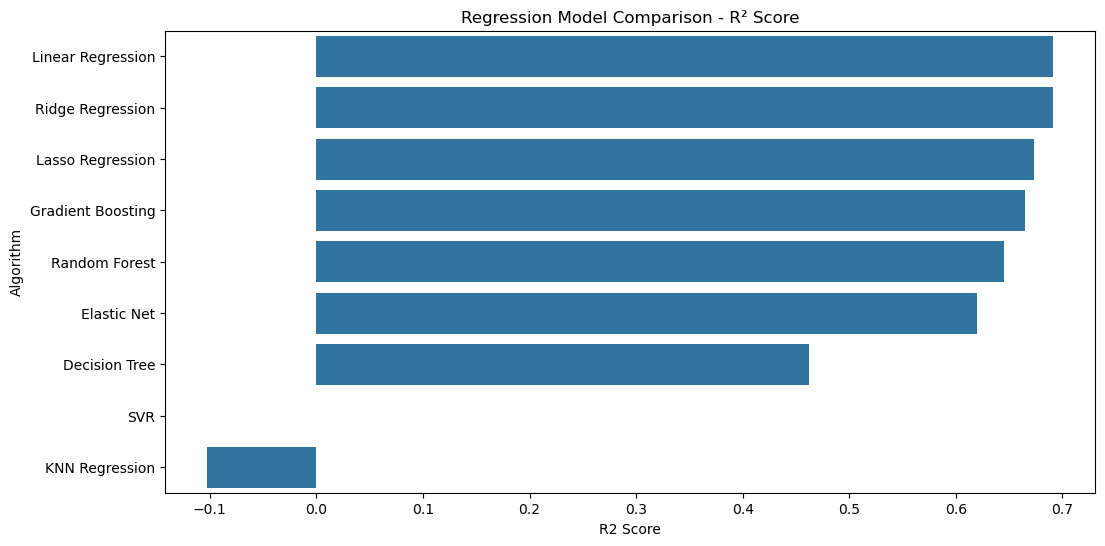

In [44]:
#Compare R² Scores
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_results,
    x='R2 Score',
    y='Algorithm'
)

plt.title('Regression Model Comparison - R² Score')
plt.show()

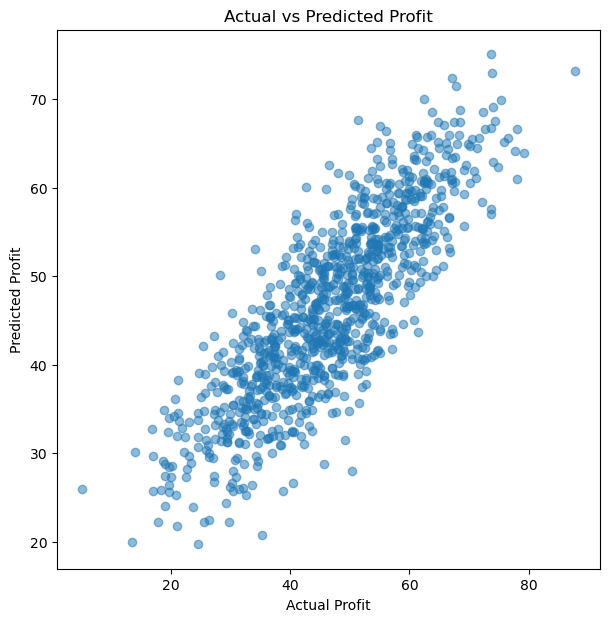

In [45]:
#Actual vs Predicted Profit
best_algorithm_name = final_results.iloc[0]['Algorithm']
best_model_object = models[best_algorithm_name]

best_predictions = best_model_object.predict(X_test_final)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

In [47]:
import pickle
import os

# Create Models folder
os.makedirs("Models", exist_ok=True)

# Save Linear Regression model
with open("Models/linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save StandardScaler
with open("Models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# Save Label Encoders
with open("Models/Farm_ID_encoder.pkl", "wb") as file:
    pickle.dump(label_encoders["Farm_ID"], file)

with open("Models/State_encoder.pkl", "wb") as file:
    pickle.dump(label_encoders["State"], file)

with open("Models/District_encoder.pkl", "wb") as file:
    pickle.dump(label_encoders["District"], file)

with open("Models/Crop_encoder.pkl", "wb") as file:
    pickle.dump(label_encoders["Crop"], file)

with open("Models/Season_encoder.pkl", "wb") as file:
    pickle.dump(label_encoders["Season"], file)

with open("Models/Irrigation_Method_encoder.pkl", "wb") as file:
    pickle.dump(label_encoders["Irrigation_Method"], file)

print("All preprocessing objects and model saved successfully!")

All preprocessing objects and model saved successfully!
